<h1 style='color:green'>Dominant Color Extraction</h1>

In [2]:
import numpy as np 
import cv2 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
img = cv2.imread('myPick.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (270,360))
print(img.shape)

(1440, 1080, 3)


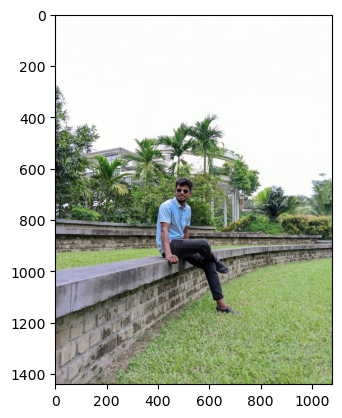

In [4]:
plt.imshow(img)
plt.show()

In [5]:
X = img.reshape((-1,3))
print(X.shape)

(1555200, 3)


In [6]:
k = 10
model = KMeans(n_clusters=k) 
model.fit(X)

KMeans(n_clusters=10)

In [7]:
centroids = model.cluster_centers_

In [8]:
print(centroids)

[[166.75151286 191.26507007 131.31200846]
 [251.90539259 253.27142383 250.73676539]
 [106.21846227 119.91919252  84.87212865]
 [ 49.09656026  62.9001655   38.93486052]
 [129.41472938 129.46610507 124.15880907]
 [138.170172   164.87307316  98.95701733]
 [157.29002008 156.57487371 156.4988809 ]
 [ 79.63738487  91.48581697  64.71640527]
 [ 18.41165983  26.80193972  15.59511843]
 [181.42276943 191.38807163 198.14544292]]


In [9]:
colors = np.array(centroids, dtype='uint8')

In [10]:
print(colors)

[[166 191 131]
 [251 253 250]
 [106 119  84]
 [ 49  62  38]
 [129 129 124]
 [138 164  98]
 [157 156 156]
 [ 79  91  64]
 [ 18  26  15]
 [181 191 198]]


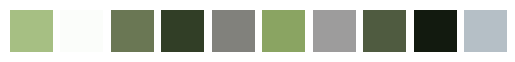

In [11]:
# Color Patch 
i = 1 
for color in colors: 
    plt.subplot(1,k,i)
    plt.axis('off')
    i+=1
    mat = np.zeros((100,100,3), dtype='uint8')
    mat[:,:,:] = color 
    plt.imshow(mat) 
plt.show()

In [12]:
np.unique(model.labels_)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
model.labels_.shape

(1555200,)

In [14]:
newImg = np.zeros((X.shape),dtype='uint8')
print(newImg.shape)
m = newImg.shape[0]

(1555200, 3)


In [15]:
for i in range(m): 
    newImg[i] = colors[model.labels_[i]]

In [16]:
newImg = newImg.reshape(img.shape)

In [17]:
print(newImg.shape)

(1440, 1080, 3)


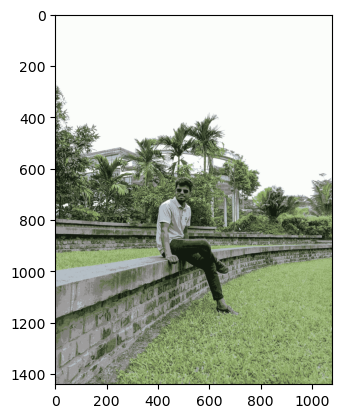

In [18]:
plt.imshow(newImg)